In [ ]:
# %%capture
# !pip install matplotlib transformers datasets accelerate sentence-transformers

**CLIP**

In [ ]:
from urllib.request import urlopen
from PIL import Image

# Load an AI-generated image of a puppy playing in the snow
puppy_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/puppy.png"
image = Image.open(urlopen(puppy_path)).convert("RGB")
caption = "a puppy playing in the snow"

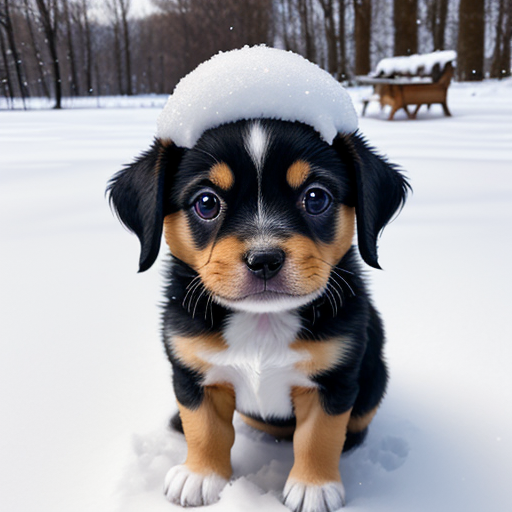

In [ ]:
image

**Embeddings**

In [ ]:
from transformers import CLIPTokenizerFast, CLIPProcessor, CLIPModel

model_id = "openai/clip-vit-base-patch32"

# Load a tokenizer to preprocess the text
clip_tokenizer = CLIPTokenizerFast.from_pretrained(model_id)

# Load a processor to preprocess the images
clip_processor = CLIPProcessor.from_pretrained(model_id)

# Main model for generating text and image embeddings
model = CLIPModel.from_pretrained(model_id)

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [ ]:
# Tokenize our input
inputs = clip_tokenizer(caption, return_tensors="pt")
inputs

{'input_ids': tensor([[49406,   320,  6829,  1629,   530,   518,  2583, 49407]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}

In [ ]:
# Convert our input back to tokens
clip_tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

['<|startoftext|>',
 'a</w>',
 'puppy</w>',
 'playing</w>',
 'in</w>',
 'the</w>',
 'snow</w>',
 '<|endoftext|>']

In [ ]:
# Create text embedding
text_embedding = model.get_text_features(**inputs)

# Get the actual tensor
text_embedding = text_embedding.pooler_output

print(text_embedding.shape)

torch.Size([1, 512])


In [ ]:
# Preprocess image
processed_image = clip_processor(
    text=None, images=image, return_tensors='pt'
)['pixel_values']

processed_image.shape

torch.Size([1, 3, 224, 224])

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

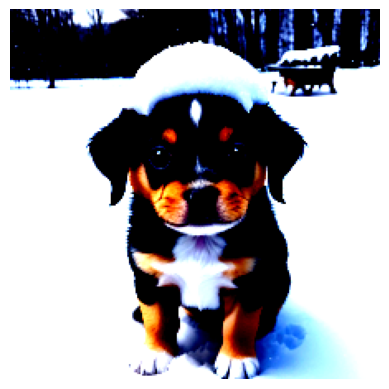

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Prepare image for visualization
img = processed_image.squeeze(0)
img = img.permute(*torch.arange(img.ndim - 1, -1, -1))
img = np.einsum('ijk->jik', img)

# Visualize preprocessed image
plt.imshow(img)
plt.axis('off')

In [ ]:
# Create the image embedding
image_embedding = model.get_image_features(processed_image)

# Get the pooled embedding
image_embedding = image_embedding.pooler_output

print(image_embedding.shape)

torch.Size([1, 512])


In [ ]:
# Normalize the embeddings
text_embedding /= text_embedding.norm(dim=-1, keepdim=True)
image_embedding /= image_embedding.norm(dim=-1, keepdim=True)

# Calculate their similarity
text_embedding = text_embedding.detach().cpu().numpy()
image_embedding = image_embedding.detach().cpu().numpy()
score = text_embedding @ image_embedding.T
score

array([[0.33146894]], dtype=float32)

**More Images**

In [ ]:
from urllib.request import urlopen
from PIL import Image
import numpy as np
import torch

# Load images
puppy_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/puppy.png"
cat_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/cat.png"
car_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/car.png"

paths = [puppy_path, cat_path, car_path]

images = [
    Image.open(urlopen(path)).convert("RGB")
    for path in paths
]

captions = [
    "a puppy playing in the snow",
    "a pixelated image of a cute cat",
    "A supercar on the road with the sunset in the background"
]


# =========================
# IMAGE EMBEDDINGS
# =========================

image_embeddings = []

for image in images:

    # Process image
    image_processed = clip_processor(
        images=image,
        return_tensors="pt"
    )["pixel_values"]

    # Create image embedding
    with torch.no_grad():

        vision_output = model.vision_model(
            pixel_values=image_processed
        )

        image_embedding = model.visual_projection(
            vision_output.pooler_output
        )

    image_embeddings.append(
        image_embedding[0].cpu().numpy()
    )

image_embeddings = np.array(image_embeddings)


# =========================
# TEXT EMBEDDINGS
# =========================

text_embeddings = []

for caption in captions:

    # Tokenize caption
    inputs = clip_tokenizer(
        caption,
        return_tensors="pt"
    )

    # Create text embedding
    with torch.no_grad():

        text_output = model.text_model(
            **inputs
        )

        text_embedding = model.text_projection(
            text_output.pooler_output
        )

    text_embeddings.append(
        text_embedding[0].cpu().numpy()
    )

text_embeddings = np.array(text_embeddings)


# =========================
# CHECK SHAPES
# =========================

print("Image embeddings shape:", image_embeddings.shape)
print("Text embeddings shape:", text_embeddings.shape)

Image embeddings shape: (3, 512)
Text embeddings shape: (3, 512)


In [ ]:
# Calculate cosine similarity between images and captions
from sklearn.metrics.pairwise import cosine_similarity
sim_matrix = cosine_similarity(image_embeddings, text_embeddings)

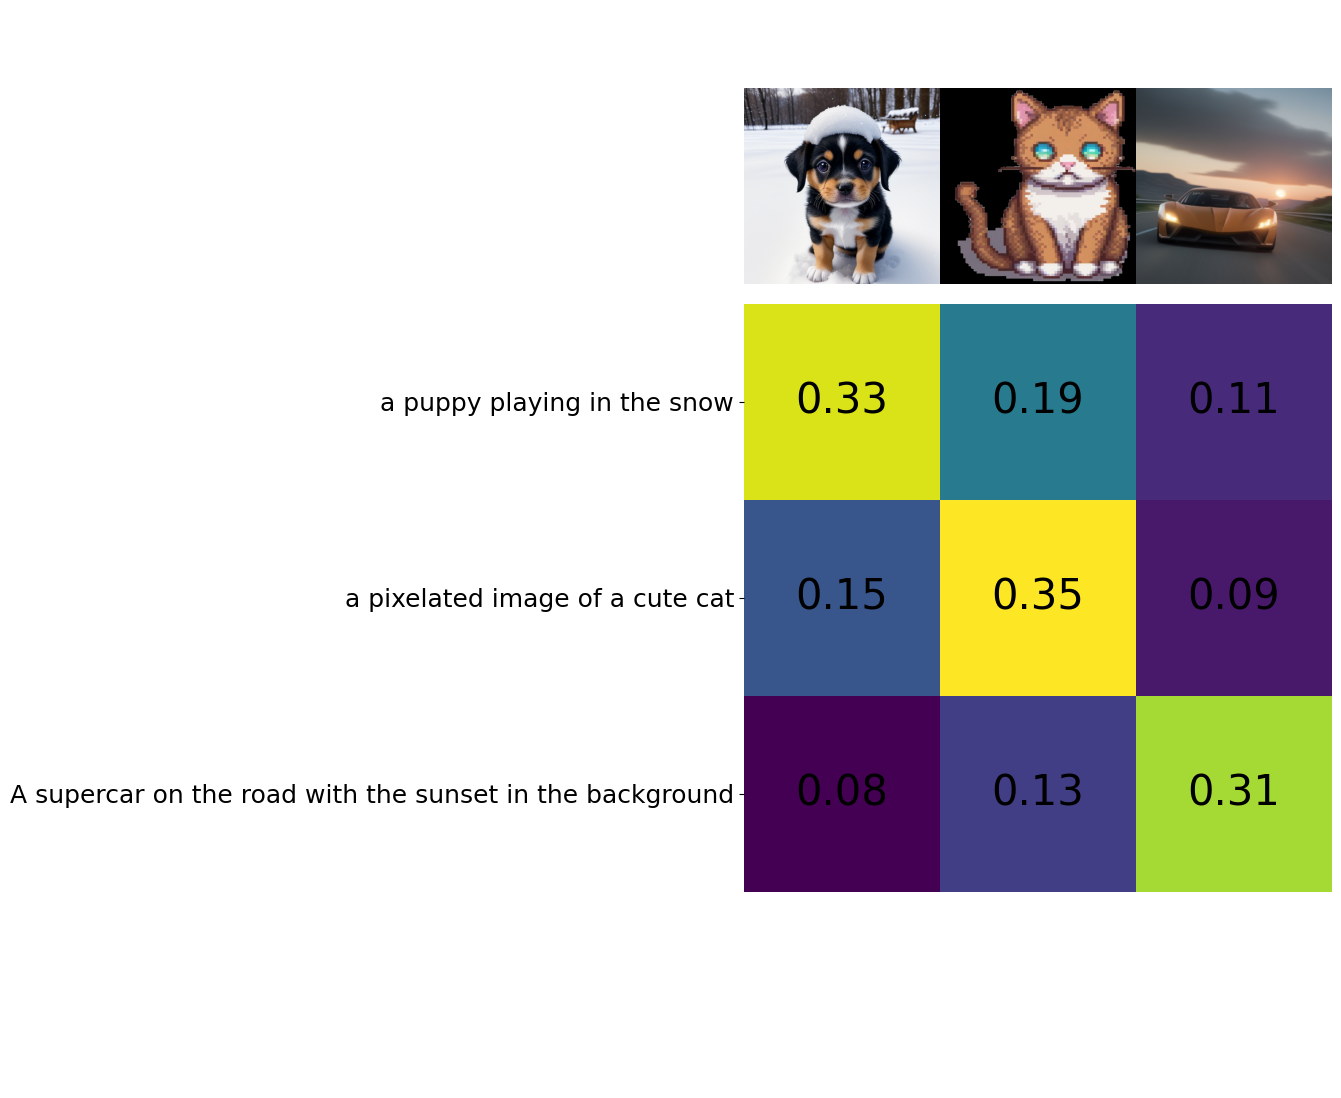

In [ ]:
# Create base figure
plt.figure(figsize=(20, 14))
plt.imshow(sim_matrix, cmap='viridis')

# Adjust ticks with correct labels
plt.yticks(range(len(captions)), captions, fontsize=18)
plt.xticks([])

# Visualize
for i, image in enumerate(images):
    plt.imshow(image, extent=(i - 0.5, i + 0.5, -1.6, -0.6), origin="lower")

# Add the captions at the correct indices
for x in range(sim_matrix.shape[1]):
    for y in range(sim_matrix.shape[0]):
        plt.text(x, y, f"{sim_matrix[y, x]:.2f}", ha="center", va="center", size=30)

# Remove unnecessary spines
for side in ["left", "top", "right", "bottom"]:
  plt.gca().spines[side].set_visible(False)

# Resize blocks
plt.xlim([-0.5, len(captions) - 0.5])
plt.ylim([len(captions) + 0.5, -2])
# plt.title("Similarity Matrix", size=20)
plt.savefig("sim_matrix.png", dpi=300, bbox_inches='tight')


**SBERT**

In [ ]:
from sentence_transformers import SentenceTransformer, util

# Load SBERT-compatible CLIP model
model = SentenceTransformer('clip-ViT-B-32')

# Encode the images
image_embeddings = model.encode(images)

# Encode the captions
text_embeddings = model.encode(captions)

#Compute cosine similarities
sim_matrix = util.cos_sim(image_embeddings, text_embeddings)
print(sim_matrix)

modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/1.91k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.03k [00:00<?, ?B/s]

0_CLIPModel/model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

tokenizer_config.json:   0%|          | 0.00/604 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tensor([[0.3315, 0.1861, 0.1085],
        [0.1488, 0.3463, 0.0947],
        [0.0762, 0.1260, 0.3098]])


**BLIP-2**

In [ ]:
from transformers import AutoProcessor, Blip2ForConditionalGeneration
import torch

# Load processor and main model
blip_processor = AutoProcessor.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    revision="51572668da0eb669e01a189dc22abe6088589a24"  # Choose specific model because of: https://huggingface.co/Salesforce/blip2-opt-2.7b/discussions/39
)
model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    revision="51572668da0eb669e01a189dc22abe6088589a24",
    torch_dtype=torch.float16
)

# Send the model to GPU to speed up inference
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/6.96k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/904 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/127k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1248 [00:00<?, ?it/s]

Blip2ForConditionalGeneration(
  (vision_model): Blip2VisionModel(
    (embeddings): Blip2VisionEmbeddings(
      (patch_embedding): Conv2d(3, 1408, kernel_size=(14, 14), stride=(14, 14))
    )
    (encoder): Blip2Encoder(
      (layers): ModuleList(
        (0-38): 39 x Blip2EncoderLayer(
          (self_attn): Blip2Attention(
            (qkv): Linear(in_features=1408, out_features=4224, bias=True)
            (projection): Linear(in_features=1408, out_features=1408, bias=True)
          )
          (layer_norm1): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
          (mlp): Blip2MLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=1408, out_features=6144, bias=True)
            (fc2): Linear(in_features=6144, out_features=1408, bias=True)
          )
          (layer_norm2): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
  )
  (qf

**Preprocessing Images**

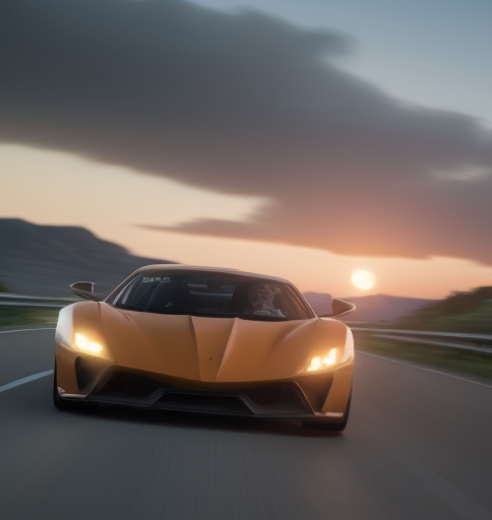

In [ ]:
from urllib.request import urlopen
from PIL import Image

# Load image of a supercar
car_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/car.png"

image = Image.open(urlopen(car_path)).convert("RGB")

image

In [ ]:
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load BLIP processor
blip_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

# Load BLIP model
blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

# Use half precision only on GPU
if device == "cuda":
    blip_model = blip_model.half()

print("BLIP loaded on:", device)

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

BLIP loaded on: cuda


In [ ]:
# Preprocess the image
inputs = blip_processor(
    image,
    return_tensors="pt"
).to(device, torch.float16)

print(inputs["pixel_values"].shape)

torch.Size([1, 3, 384, 384])


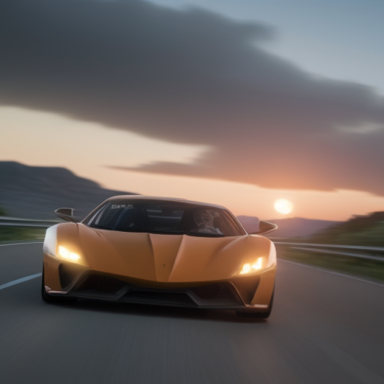

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from PIL import Image

# Convert to numpy and go from (1, 3, 224, 224) to (224, 224, 3)
image_inputs = inputs["pixel_values"][0].detach().cpu().numpy()

image_inputs = np.einsum('ijk->kji', image_inputs)
image_inputs = np.einsum('ijk->jik', image_inputs)

# Scale image inputs to 0-255 to represent RGB values
scaler = MinMaxScaler(feature_range=(0, 255))

image_inputs = scaler.fit_transform(
    image_inputs.reshape(-1, image_inputs.shape[-1])
).reshape(image_inputs.shape)

image_inputs = np.array(image_inputs, dtype=np.uint8)

# Convert numpy array to Image
Image.fromarray(image_inputs)

**Preprocessing Text**

In [ ]:
blip_processor.tokenizer

BertTokenizer(name_or_path='Salesforce/blip-image-captioning-base', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [ ]:
# Preprocess the text
text = "Her vocalization was remarkably melodic"
token_ids = blip_processor(image, text=text, return_tensors="pt")
token_ids = token_ids.to(device, torch.float16)["input_ids"][0]

# Convert input ids back to tokens
tokens = blip_processor.tokenizer.convert_ids_to_tokens(token_ids)
tokens

['[CLS]', 'her', 'vocal', '##ization', 'was', 'remarkably', 'melodic', '[SEP]']

In [ ]:
# Replace the space token with an underscore
tokens = [token.replace("Ġ", "_") for token in tokens]
tokens

['[CLS]', 'her', 'vocal', '##ization', 'was', 'remarkably', 'melodic', '[SEP]']

**Use Case 1: Image Captioning**

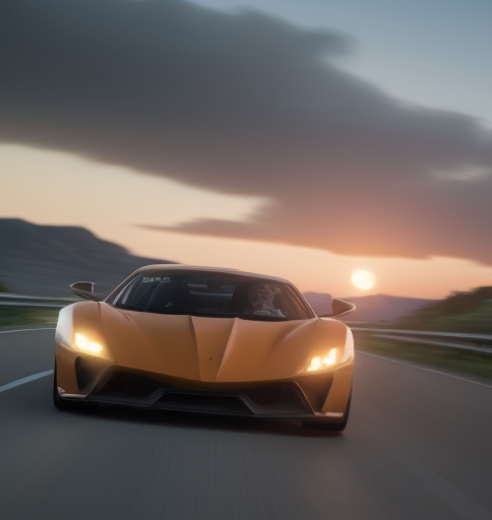

In [ ]:
# Load an AI-generated image of a supercar
image = Image.open(urlopen(car_path)).convert("RGB")

# Convert an image into inputs and preprocess it
inputs = blip_processor(image, return_tensors="pt").to(device, torch.float16)
image

In [ ]:
# Generate image ids to be passed to the decoder (LLM)
generated_ids = blip_model.generate(
    **inputs,
    max_new_tokens=20
)

# Generate text from the image ids
generated_text = blip_processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)

generated_text = generated_text[0].strip()

generated_text

'a yellow sports car driving down a road'

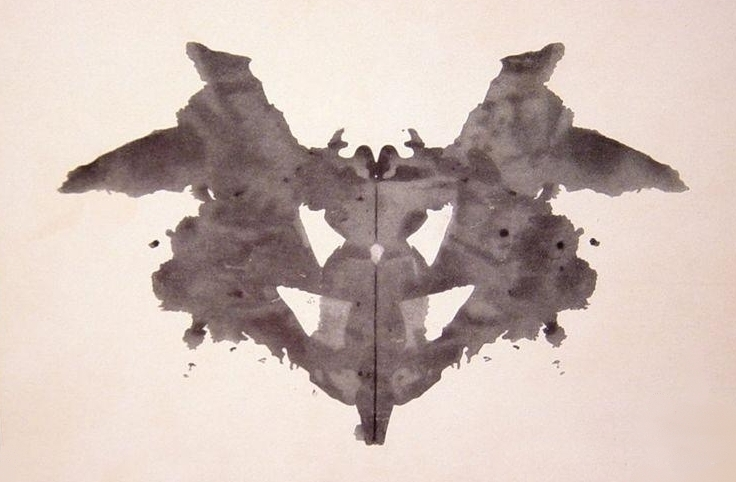

In [ ]:
from urllib.request import Request, urlopen
from PIL import Image

url = "https://upload.wikimedia.org/wikipedia/commons/7/70/Rorschach_blot_01.jpg"

# Create request with a User-Agent
request = Request(
    url,
    headers={
        "User-Agent": "Mozilla/5.0"
    }
)

# Download and open image
image = Image.open(urlopen(request)).convert("RGB")

image

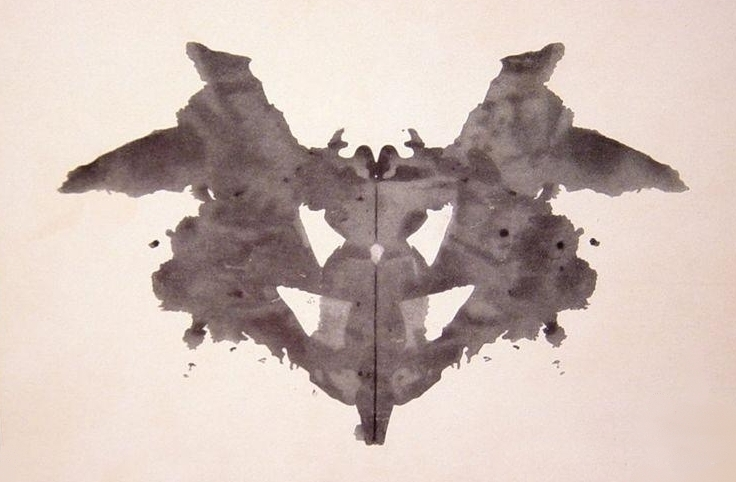

a black ink stain on a white paper


In [ ]:
from urllib.request import Request, urlopen
from PIL import Image
import torch

# Load Rorschach image
url = "https://upload.wikimedia.org/wikipedia/commons/7/70/Rorschach_blot_01.jpg"

request = Request(
    url,
    headers={
        "User-Agent": "Mozilla/5.0"
    }
)

image = Image.open(urlopen(request)).convert("RGB")

# Display image
display(image)


# Generate caption
if device == "cuda":
    inputs = blip_processor(
        image,
        return_tensors="pt"
    ).to(device, torch.float16)
else:
    inputs = blip_processor(
        image,
        return_tensors="pt"
    ).to(device)

generated_ids = blip_model.generate(
    **inputs,
    max_new_tokens=20
)

generated_text = blip_processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)

generated_text = generated_text[0].strip()

print(generated_text)

**Use Case 2: Visual Question Answering**

In [ ]:
# Load an AI-generated image of a supercar
image = Image.open(urlopen(car_path)).convert("RGB")

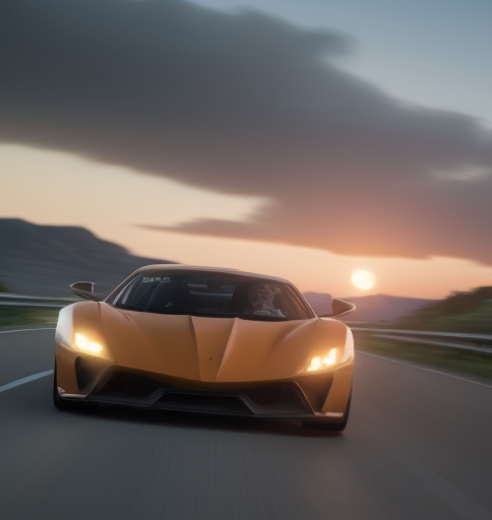

a yellow sports car driving down a road


In [ ]:
# Load the supercar image
from urllib.request import Request, urlopen
from PIL import Image
import torch

car_url = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/car.png"

request = Request(
    car_url,
    headers={"User-Agent": "Mozilla/5.0"}
)

image = Image.open(urlopen(request)).convert("RGB")

display(image)


# Generate caption
if device == "cuda":
    inputs = blip_processor(
        image,
        return_tensors="pt"
    ).to(device, torch.float16)
else:
    inputs = blip_processor(
        image,
        return_tensors="pt"
    ).to(device)

generated_ids = blip_model.generate(
    **inputs,
    max_new_tokens=30
)

generated_text = blip_processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0].strip()

print(generated_text)

In [ ]:
# Chat-like prompting

prompt = (
    "Question: Write down what you see in this picture. "
    "Answer: A sports car driving on the road at sunset. "
    "Question: What would it cost me to drive that car? "
    "Answer:"
)

# Process image and prompt
if device == "cuda":
    inputs = blip_processor(
        image,
        text=prompt,
        return_tensors="pt"
    ).to(device, torch.float16)
else:
    inputs = blip_processor(
        image,
        text=prompt,
        return_tensors="pt"
    ).to(device)

# Generate
with torch.no_grad():
    generated_ids = blip_model.generate(
        **inputs,
        max_new_tokens=10,
        num_beams=5,
        early_stopping=True
    )

# Decode
generated_text = blip_processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0].strip()

print(generated_text)

question : write down what you see in this picture. answer : a sports car driving on the road at sunset. question : what would it cost me to drive that car? answer :


In [ ]:
from IPython.display import HTML, display
import ipywidgets as widgets

def text_eventhandler(*args):
  question = args[0]["new"]
  if question:
    args[0]["owner"].value = ""

    # Create prompt
    if not memory:
      prompt = " Question: " + question + " Answer:"
    else:
      template = "Question: {} Answer: {}."
      prompt = " ".join(
          [
              template.format(memory[i][0], memory[i][1])
              for i in range(len(memory))
          ]
      ) + " Question: " + question + " Answer:"

    # Generate text
    inputs = blip_processor(image, text=prompt, return_tensors="pt")
    inputs = inputs.to(device, torch.float16)
    generated_ids = model.generate(**inputs, max_new_tokens=100)
    generated_text = blip_processor.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )
    generated_text = generated_text[0].strip().split("Question")[0]

    # Update memory
    memory.append((question, generated_text))

    # Assign to output
    output.append_display_data(HTML("<b>USER:</b> " + question))
    output.append_display_data(HTML("<b>BLIP-2:</b> " + generated_text))
    output.append_display_data(HTML("<br>"))

# Prepare widgets
in_text = widgets.Text()
in_text.continuous_update = False
in_text.observe(text_eventhandler, "value")
output = widgets.Output()
memory = []

# Display chat box
display(
    widgets.VBox(
        children=[output, in_text],
        layout=widgets.Layout(display="inline-flex", flex_flow="column-reverse"),
    )
)